## Artefato de matemática 

### Definição de hipóteses 

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import lilliefors
import scipy.stats as norm


df = pd.read_csv('../dados/data.csv')
df.head()




,id_grupo,id_beneficiario,Numero_do_boleto,data_inclusao,status_boleto,data_vencto,vl_boleto,dt_pagto,vl_pagto,banco,id_pagador,pagador_cep,pagador_cidade,qtd_acessos_pagador,pagador_dt_ultimo_acesso,pagador_cnpjcpf
0,41,129,377066685,2024-06-25,LIQUIDADO,2024-07-22,240.65,2024-07-05,223.80,BANCO SANTANDER (BRASIL) S.A.,1197085,2814020,SAO PAULO,\N,\N,CPF
1,41,129,377066686,2024-06-25,LIQUIDADO,2024-07-22,155.33,2024-07-25,158.54,BANCO SANTANDER (BRASIL) S.A.,18801125,2963040,SAO PAULO,\N,\N,CPF
2,41,129,377066687,2024-06-25,LIQUIDADO,2024-07-22,325.52,2024-07-08,302.73,BANCO SANTANDER (BRASIL) S.A.,2736794,2925060,SAO PAULO,2,2024-06-26 08:59:14,CPF
3,41,129,377066689,2024-06-25,LIQUIDADO,2024-07-22,325.52,2024-07-09,302.73,BANCO SANTANDER (BRASIL) S.A.,18801124,2969030,SAO PAULO,\N,\N,CPF
4,41,129,377066691,2024-06-25,LIQUIDADO,2024-07-22,290.97,2024-06-28,290.97,BANCO SANTANDER (BRASIL) S.A.,18801128,2737070,SAO PAULO,\N,\N,CPF


Hipótese 1: <br>
H0: A variável vl_boleto (valor do boleto) segue a distribuição normal <br>
HA: A variável vl_boleto (valor do boleto) não segue a distribuição normal 

In [35]:
# Calculando p_value da hipótese 1 
stat, p_value = lilliefors(df['vl_boleto'])
print("o valor de p_value é:", p_value)

o valor de p_value é: 0.0009999999999998899


O *p_value* referente a distribuiçã normal da variável *vl_boleto* é de 0.00099999. Logo *p_value* é menor do que o nível de significância 0.005 e por isso a hipótese HA (A variável *vl_boleto* não segue a distribuição normal), é a correta.

Hipótese 2: <br>
H0: A variável  vl_pagto (valor do pagamento) segue a distribuição normal <br>
HA: A variável vl_pagto (valor do pagamento) não segue a distribuição normal 

In [ ]:
# Calculando p_value da hipótese 2
df['vl_pagto'] = df['vl_pagto'].replace('\\N', np.nan)
stat, p_value1 = lilliefors(df['vl_pagto'].dropna().astype(float))
print("o valor de p_value é:", p_value1)

o valor de p_value é: 0.0009999999999998899


Hipótese 3: <br>
H0: A variável  qtd_acessos_pagador (quantidade de acessos do pagador) segue a distribuição normal <br>
HA: A variável qtd_acessos_pagador não segue a distribuição normal 

In [ ]:
# calculando p_value da hipóese 3
df['qtd_acessos_pagador'] = df['qtd_acessos_pagador'].replace('\\N', np.nan)
stat, p_value1 = lilliefors(df['qtd_acessos_pagador'].dropna().astype(float))
print("o valor de p_value é:", p_value1)

o valor de p_value é: 0.0009999999999998899


O *p_value* referente a distribuiçã normal da variável *qtd_acessos_pagador* é de 0.00099999. Logo p_value é menor do que o nível de significância 0.005 e por isso a hipótese HA (A variável qtd_acessos_pagador refernte quantidade de acessos por partes dos pagadores dos boletos não segue a distribuição normal), é a correta.

### Construção de histograma das variáveis 

#### Valor do boleto (vl_boleto)

Média do valor do boleto: 303.65463836044484
Mediana do valor do boleto: 305.17


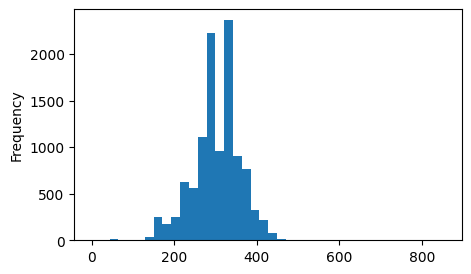

In [45]:
df['vl_boleto'].plot(kind='hist', bins=40, figsize=(5, 3))
media_boleto = df['vl_boleto'].mean()
print("Média do valor do boleto:", media_boleto)
mediana_boleto = df['vl_boleto'].median()
print("Mediana do valor do boleto:", mediana_boleto)

O valor da média (303,65) e da mediana (305,17) da variável de valor do boleto (vl_pagto) são que sugere uma distribuição que se aproxima da normalidade, o que é visível no gráfco em que a distribuição de valores aparenta seguir uma simetria. No entanto, após a  aplicação do teste de normalidade, utilizando a biblioteca lilliefors, calculou-se  que a distribuição da variável não é normal. Isso ocorre pois em amostras grandes pequenos desvios de normalidade são dectectados pelo teste, mesmo que isso não sejá visível a olho.

#### valor do pagamento do boleto (vl_pagto)

Média do valor do pagamento: 300.16602450469236
Mediana do valor do pagamento: 300.9


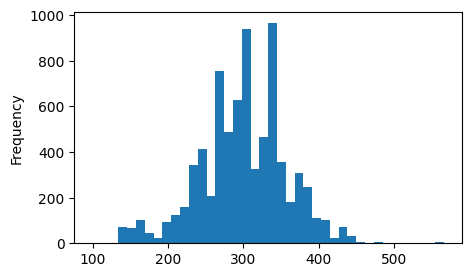

In [39]:
df['vl_pagto'] = pd.to_numeric(df['vl_pagto'], errors='coerce')
df['vl_pagto'].plot(kind='hist', bins=40, figsize=(5, 3))
media_pagto = df['vl_pagto'].mean()
print("Média do valor do pagamento:", media_pagto)
mediana_pagto = df['vl_pagto'].median()
print("Mediana do valor do pagamento:", mediana_pagto)

O valor da média (300,17) e da mediana (300,9) da variável de valor de pagamento (vl_pagto) são bem próximos o que sugere uma distribuição simétrica que se aproxima da normalidade, o que é visível no histograma da variável. No entanto, após a aplicação do teste de normalidade, utilizando a biblioteca lilliefors, calculou-se que a distribuição da variável não é normal.

#### Quantidade de acessos dos pagadores no boleto (qtd_acessos_pagador)

Média da quantidade de acessos dos pagadores: 3.1991584852734922
Mediana da quantidade de acessos dos pagadores: 2.0


<Axes: ylabel='Frequency'>

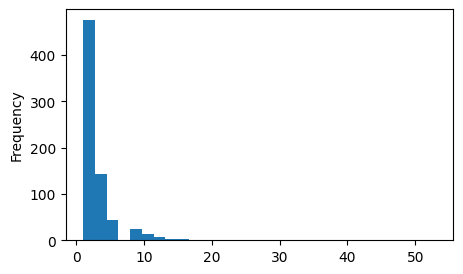

In [44]:
df['qtd_acessos_pagador'] = pd.to_numeric(df['qtd_acessos_pagador'], errors='coerce')
qtd_acessos_pagador_mean = df['qtd_acessos_pagador'].mean()
qtd_acessos_pagador_median = df['qtd_acessos_pagador'].median()
print("Média da quantidade de acessos dos pagadores:", qtd_acessos_pagador_mean)
print("Mediana da quantidade de acessos dos pagadores:", qtd_acessos_pagador_median)
df['qtd_acessos_pagador'].plot(kind='hist', bins=30, figsize=(5, 3))

A média (3,19) e mediana (2,0) da variável que representa a quantidade de acessos do pagador (qtd_acessos_pagador) possuem valores consideravelmente distantes sugerindo uma distribuição não normal, que é também visiível no gráfico da variável e comprovado pelo teste de normalidade que foi utilizado utilizando a biblioteca lilliefors 